# Hybrid Model: CNN-BiLSTM + NeuroTalk Multi-Receptive ResBlocks

## لماذا هذا النهج؟

| المشكلة | الحل |
|---------|------|
| NeuroTalk من الصفر أعطى PCC=0.148 | نستخدم CNN-BiLSTM المُثبت كأساس |
| لا يوجد pretrained weights فعلية | نستخدم **الموديل الأصلي كـ pretrained** ثم نضيف NeuroTalk blocks |
| البيانات قليلة (796 عينة) | نبدأ من checkpoint ناجح بدل التدريب من الصفر |

## الاستراتيجية:
1. **المرحلة الأولى**: تدريب CNN-BiLSTM الأصلي (baseline)
2. **المرحلة الثانية**: إدراج Multi-Receptive ResBlocks من NeuroTalk
3. **المرحلة الثالثة**: Transfer weights من المرحلة 1 → 2 + fine-tune

### المساهمة العلمية المقترحة:
- أول عمل يدمج Multi-Receptive Residual Blocks مع BiLSTM في EEG-to-Speech
- دراسة multi-subject مع channel masking (عدد قنوات مختلف لكل شخص)
- إثبات أن Transfer Learning من baseline بسيط → بنية معقدة فعّال

In [1]:
# ============================================================
# STEP 0: Imports + Settings + Seed
# ============================================================
import os, copy, random, math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# ---------- SETTINGS ----------
MANIFEST_CSV = r"C:\Users\PC\Desktop\courses\Conferences\Sevile\test\dataset\manifest_pairs.csv"
ALL_SUBJECTS = ["SUB1","SUB2","SUB3","SUB4","SUB5","SUB6","SUB7","SUB8","SUB9","SUB10"]

TARGET_CH  = 127
T_FIXED    = 1349
MEL_BINS   = 80
MEL_FRAMES = 259

BATCH_SIZE   = 4
PATIENCE     = 8
WEIGHT_DECAY = 1e-4

# Phase 1: Train baseline CNN-BiLSTM
EPOCHS_BASELINE = 60
LR_BASELINE     = 1e-4

# Phase 2: Fine-tune hybrid model
EPOCHS_HYBRID   = 60
LR_HYBRID       = 5e-5   # أقل لأننا نبدأ من checkpoint جيد

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- SEED ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f"Device: {device}")

Device: cpu


In [2]:
# ============================================================
# STEP 1: Utility Functions (Time crop/pad)
# ============================================================
def pad_or_crop_time(x, T_fixed=T_FIXED):
    C, T = x.shape
    if T == T_fixed: return x
    if T > T_fixed:  return x[:, :T_fixed]
    out = np.zeros((C, T_fixed), dtype=x.dtype)
    out[:, :T] = x
    return out

def center_crop_time(x, T_fixed=T_FIXED):
    C, T = x.shape
    if T <= T_fixed: return pad_or_crop_time(x, T_fixed)
    start = (T - T_fixed) // 2
    return x[:, start:start + T_fixed]

def random_crop_time(x, T_fixed=T_FIXED):
    C, T = x.shape
    if T <= T_fixed: return pad_or_crop_time(x, T_fixed)
    start = np.random.randint(0, T - T_fixed + 1)
    return x[:, start:start + T_fixed]

print("✅ Utility functions ready")

✅ Utility functions ready


In [3]:
# ============================================================
# STEP 2: Per-Subject EEG Statistics
# ============================================================
def compute_eeg_stats_train(manifest_csv, subject):
    df = pd.read_csv(manifest_csv)
    df = df[(df["subject"] == subject) & (df["split"] == "train")].reset_index(drop=True)
    sum_c = sumsq_c = None
    count_t = 0
    for p in df["eeg_path"].tolist():
        x = np.load(p)
        if x.shape[0] > x.shape[1]: x = x.T
        x = x.astype(np.float64)
        if sum_c is None:
            sum_c   = x.sum(axis=1)
            sumsq_c = (x**2).sum(axis=1)
        else:
            sum_c   += x.sum(axis=1)
            sumsq_c += (x**2).sum(axis=1)
        count_t += x.shape[1]
    mean = (sum_c / count_t).astype(np.float32)
    var  = (sumsq_c / count_t - mean.astype(np.float64)**2).astype(np.float32)
    std  = np.sqrt(np.maximum(var, 1e-8)).astype(np.float32)
    return mean, std

eeg_stats = {s: compute_eeg_stats_train(MANIFEST_CSV, s) for s in ALL_SUBJECTS}
print("✅ Computed stats for", len(eeg_stats), "subjects")

✅ Computed stats for 10 subjects


In [4]:
# ============================================================
# STEP 3: Dataset
# ============================================================
class MultiSubjectMaskedDataset(Dataset):
    def __init__(self, manifest_csv, split, subjects, eeg_stats):
        self.df = pd.read_csv(manifest_csv)
        self.df = self.df[(self.df["split"] == split) &
                          (self.df["subject"].isin(subjects))].reset_index(drop=True)
        self.split     = split
        self.subjects  = list(subjects)
        self.sub2idx   = {s: i for i, s in enumerate(self.subjects)}
        self.eeg_stats = eeg_stats

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        subj = row["subject"]
        eeg  = np.load(row["eeg_path"])
        if eeg.shape[0] > eeg.shape[1]: eeg = eeg.T
        eeg = eeg.astype(np.float32)
        mel = np.load(row["mel_path"]).astype(np.float32)

        mean, std = self.eeg_stats[subj]
        eeg = (eeg - mean[:, None]) / (std[:, None] + 1e-8)

        C, T = eeg.shape
        eeg_pad = np.zeros((TARGET_CH, T), dtype=np.float32)
        eeg_pad[:C, :] = eeg
        mask = np.zeros((TARGET_CH, 1), dtype=np.float32)
        mask[:C, 0] = 1.0

        if self.split == "train":
            eeg_pad = random_crop_time(eeg_pad)
        else:
            eeg_pad = center_crop_time(eeg_pad)

        sid = self.sub2idx[subj]
        return (torch.from_numpy(eeg_pad), torch.from_numpy(mel),
                torch.from_numpy(mask), torch.tensor(sid, dtype=torch.long))

print("✅ Dataset class defined")

✅ Dataset class defined


In [5]:
# ============================================================
# STEP 4: DataLoaders
# ============================================================
train_set = MultiSubjectMaskedDataset(MANIFEST_CSV, "train", ALL_SUBJECTS, eeg_stats)
val_set   = MultiSubjectMaskedDataset(MANIFEST_CSV, "val",   ALL_SUBJECTS, eeg_stats)
test_set  = MultiSubjectMaskedDataset(MANIFEST_CSV, "test",  ALL_SUBJECTS, eeg_stats)

sub_counts = train_set.df["subject"].value_counts().to_dict()
weights = [1.0 / sub_counts[s] for s in train_set.df["subject"].tolist()]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,  num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,  num_workers=0)

print(f"✅ Loaders: Train={len(train_set)}, Val={len(val_set)}, Test={len(test_set)}")

✅ Loaders: Train=796, Val=99, Test=101


In [6]:
# ============================================================
# STEP 5-A: Baseline Model (CNN-BiLSTM) — نفس الأصلي بالضبط
# ============================================================
class CNNBiLSTM_SubjectEmbed(nn.Module):
    """Baseline model - same as original."""
    def __init__(self, n_subjects=10, embed_dim=32, hidden=256):
        super().__init__()
        self.sub_embed = nn.Embedding(n_subjects, embed_dim)
        self.encoder = nn.Sequential(
            nn.Conv1d(TARGET_CH, 128, kernel_size=7, padding=3), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 256, kernel_size=7, padding=3),       nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(256, 256, kernel_size=7, padding=3),       nn.ReLU(), nn.MaxPool1d(2),
        )
        self.time_pool = nn.AdaptiveAvgPool1d(MEL_FRAMES)
        self.bilstm = nn.LSTM(input_size=256 + embed_dim, hidden_size=hidden,
                              num_layers=1, batch_first=True, bidirectional=True)
        self.proj = nn.Linear(hidden * 2, MEL_BINS)

    def forward(self, x, mask, sid):
        x = x * mask
        z = self.encoder(x)
        z = self.time_pool(z)
        z = z.permute(0, 2, 1)
        e = self.sub_embed(sid).unsqueeze(1).repeat(1, z.size(1), 1)
        z = torch.cat([z, e], dim=-1)
        z, _ = self.bilstm(z)
        z = self.proj(z)
        z = z.permute(0, 2, 1)
        return z

print("✅ Baseline CNN-BiLSTM defined")

✅ Baseline CNN-BiLSTM defined


In [7]:
# ============================================================
# STEP 5-B: NeuroTalk Multi-Receptive ResBlock
# ============================================================
class MultiReceptiveResBlock(nn.Module):
    """
    Core component from NeuroTalk (Lee et al., AAAI 2023).
    Parallel Conv1d with kernels 3,5,7 → merge → residual.
    Captures multi-scale frequency characteristics.
    """
    def __init__(self, channels):
        super().__init__()
        self.conv_k3 = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels), nn.LeakyReLU(0.2))
        self.conv_k5 = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(channels), nn.LeakyReLU(0.2))
        self.conv_k7 = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(channels), nn.LeakyReLU(0.2))
        self.merge = nn.Sequential(
            nn.Conv1d(channels * 3, channels, kernel_size=1),
            nn.BatchNorm1d(channels), nn.LeakyReLU(0.2))
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        h = torch.cat([self.conv_k3(x), self.conv_k5(x), self.conv_k7(x)], dim=1)
        return x + self.dropout(self.merge(h))

print("✅ MultiReceptiveResBlock defined")

✅ MultiReceptiveResBlock defined


In [8]:
# ============================================================
# STEP 5-C: Hybrid Model (CNN-BiLSTM + NeuroTalk ResBlocks)
# ============================================================
#
# الفكرة: نأخذ CNN-BiLSTM الأصلي ونُدخل NeuroTalk ResBlocks
# في 3 مواقع استراتيجية:
#   1. بعد كل طبقة Conv في الـ encoder
#   2. قبل الـ BiLSTM (refinement)
#   3. بعد الـ BiLSTM (post-processing)
#
# الـ CNN encoder layers تبقى نفسها → يمكن نقل الـ weights
# الـ BiLSTM يبقى نفسه → يمكن نقل الـ weights
# فقط NeuroTalk ResBlocks جديدة → تتدرب من الصفر

class HybridNeuroTalk(nn.Module):
    """
    Hybrid: Original CNN-BiLSTM backbone + NeuroTalk Multi-Receptive ResBlocks.
    
    Architecture:
    EEG → [Conv1→MRResBlock] → [Conv2→MRResBlock] → [Conv3→MRResBlock]
        → Pool → [MRResBlock_pre] → BiLSTM → [MRResBlock_post] → Mel
    
    Transfer: Conv1-3 + BiLSTM weights loaded from baseline checkpoint.
    """
    def __init__(self, n_subjects=10, embed_dim=32, hidden=256):
        super().__init__()
        
        self.sub_embed = nn.Embedding(n_subjects, embed_dim)
        
        # ---- Original CNN Encoder (weights transferable) ----
        self.conv1 = nn.Sequential(
            nn.Conv1d(TARGET_CH, 128, kernel_size=7, padding=3),
            nn.ReLU(), nn.MaxPool1d(2))
        self.conv2 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=7, padding=3),
            nn.ReLU(), nn.MaxPool1d(2))
        self.conv3 = nn.Sequential(
            nn.Conv1d(256, 256, kernel_size=7, padding=3),
            nn.ReLU(), nn.MaxPool1d(2))
        
        # ---- NeuroTalk Multi-Receptive ResBlocks (جديدة) ----
        self.mr_res1 = MultiReceptiveResBlock(128)   # بعد conv1
        self.mr_res2 = MultiReceptiveResBlock(256)   # بعد conv2
        self.mr_res3 = MultiReceptiveResBlock(256)   # بعد conv3
        self.mr_pre_lstm = MultiReceptiveResBlock(256)  # قبل BiLSTM
        
        self.time_pool = nn.AdaptiveAvgPool1d(MEL_FRAMES)
        
        # ---- Original BiLSTM (weights transferable) ----
        self.bilstm = nn.LSTM(
            input_size=256 + embed_dim,
            hidden_size=hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        
        # ---- Post-LSTM NeuroTalk refinement (جديد) ----
        self.post_lstm_proj = nn.Linear(hidden * 2, 256)
        self.mr_post_lstm  = MultiReceptiveResBlock(256)
        
        # ---- Final projection ----
        self.proj = nn.Linear(256, MEL_BINS)
    
    def forward(self, x, mask, sid):
        # x: (B, 127, T), mask: (B, 127, 1)
        x = x * mask
        
        # Encoder with interleaved NeuroTalk ResBlocks
        z = self.conv1(x)            # (B, 128, T/2)
        z = self.mr_res1(z)          # ← NeuroTalk: multi-receptive features
        
        z = self.conv2(z)            # (B, 256, T/4)
        z = self.mr_res2(z)          # ← NeuroTalk
        
        z = self.conv3(z)            # (B, 256, T/8)
        z = self.mr_res3(z)          # ← NeuroTalk
        z = self.mr_pre_lstm(z)      # ← NeuroTalk: pre-LSTM refinement
        
        z = self.time_pool(z)        # (B, 256, 259)
        z = z.permute(0, 2, 1)       # (B, 259, 256)
        
        # Subject embedding
        e = self.sub_embed(sid)      # (B, embed_dim)
        e = e.unsqueeze(1).repeat(1, z.size(1), 1)  # (B, 259, embed_dim)
        z = torch.cat([z, e], dim=-1)  # (B, 259, 256+embed_dim)
        
        # BiLSTM
        z, _ = self.bilstm(z)        # (B, 259, 512)
        
        # Post-LSTM NeuroTalk refinement
        z = self.post_lstm_proj(z)   # (B, 259, 256)
        z = z.permute(0, 2, 1)       # (B, 256, 259)
        z = self.mr_post_lstm(z)     # ← NeuroTalk: post-LSTM refinement
        z = z.permute(0, 2, 1)       # (B, 259, 256)
        
        # Final projection
        z = self.proj(z)             # (B, 259, 80)
        z = z.permute(0, 2, 1)       # (B, 80, 259)
        return z


# ---- إحصائيات الموديل ----
_m = HybridNeuroTalk(n_subjects=10)
total    = sum(p.numel() for p in _m.parameters())
new_only = sum(p.numel() for n, p in _m.named_parameters()
               if 'mr_res' in n or 'mr_pre' in n or 'mr_post' in n or 'post_lstm_proj' in n)
old_transferable = total - new_only
print(f"✅ Hybrid NeuroTalk Model")
print(f"   Total params:        {total:,}")
print(f"   Transferable (old):  {old_transferable:,}")
print(f"   New (NeuroTalk):     {new_only:,}")
del _m

✅ Hybrid NeuroTalk Model
   Total params:        7,100,304
   Transferable (old):  1,941,648
   New (NeuroTalk):     5,158,656


In [9]:
# ============================================================
# STEP 6: Phase 1 — Train Baseline CNN-BiLSTM
# ============================================================
# (إذا عندك checkpoint سابق، يمكن تخطي هذه الخلية وتحميله مباشرة)

CKPT_BASELINE = "baseline_cnn_bilstm_best.pt"

baseline = CNNBiLSTM_SubjectEmbed(
    n_subjects=len(ALL_SUBJECTS), embed_dim=32, hidden=256
).to(device)

criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(baseline.parameters(), lr=LR_BASELINE, weight_decay=WEIGHT_DECAY)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2)

def run_epoch(model, loader, optimizer=None, train=True):
    model.train() if train else model.eval()
    total, n = 0.0, 0
    for xb, yb, mask, sid in loader:
        xb, yb = xb.to(device), yb.to(device)
        mask, sid = mask.to(device), sid.to(device)
        yp   = model(xb, mask, sid)
        loss = criterion(yp, yb)
        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        total += loss.item() * xb.size(0)
        n     += xb.size(0)
    return total / max(n, 1)

print("="*60)
print("PHASE 1: Training Baseline CNN-BiLSTM")
print("="*60)

best_val = float("inf")
best_ep  = -1
pat = 0

for epoch in range(1, EPOCHS_BASELINE + 1):
    tr = run_epoch(baseline, train_loader, optimizer, train=True)
    va = run_epoch(baseline, val_loader,   train=False)
    scheduler.step(va)
    lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:02d} | Train {tr:.4f} | Val {va:.4f} | LR {lr:.2e}")
    
    if va < best_val:
        best_val, best_ep, pat = va, epoch, 0
        torch.save(baseline.state_dict(), CKPT_BASELINE)
        print(f"  ✅ Saved: {CKPT_BASELINE}")
    else:
        pat += 1
        if pat >= PATIENCE:
            print(f"  🛑 Early stopping at epoch {epoch}")
            break

print(f"\n✅ Baseline done. Best epoch={best_ep}, Val={best_val:.4f}")

PHASE 1: Training Baseline CNN-BiLSTM
Epoch 01 | Train 27.3247 | Val 4.4801 | LR 1.00e-04
  ✅ Saved: baseline_cnn_bilstm_best.pt
Epoch 02 | Train 4.5917 | Val 4.4748 | LR 1.00e-04
  ✅ Saved: baseline_cnn_bilstm_best.pt
Epoch 03 | Train 4.6262 | Val 4.4703 | LR 1.00e-04
  ✅ Saved: baseline_cnn_bilstm_best.pt
Epoch 04 | Train 4.6214 | Val 4.4712 | LR 1.00e-04
Epoch 05 | Train 4.5914 | Val 4.4781 | LR 1.00e-04
Epoch 06 | Train 4.6123 | Val 4.4699 | LR 5.00e-05
  ✅ Saved: baseline_cnn_bilstm_best.pt
Epoch 07 | Train 4.5574 | Val 4.4629 | LR 5.00e-05
  ✅ Saved: baseline_cnn_bilstm_best.pt
Epoch 08 | Train 4.5944 | Val 4.4634 | LR 5.00e-05
Epoch 09 | Train 4.5396 | Val 4.4661 | LR 5.00e-05
Epoch 10 | Train 4.5829 | Val 4.4656 | LR 2.50e-05
Epoch 11 | Train 4.5062 | Val 4.4628 | LR 2.50e-05
  ✅ Saved: baseline_cnn_bilstm_best.pt
Epoch 12 | Train 4.4972 | Val 4.4645 | LR 2.50e-05
Epoch 13 | Train 4.5588 | Val 4.4653 | LR 1.25e-05
Epoch 14 | Train 4.5153 | Val 4.4642 | LR 1.25e-05
Epoch 15 | Tr

In [10]:
# ============================================================
# STEP 7: Transfer Weights — Baseline → Hybrid
# ============================================================
# هذه هي الخطوة المفتاحية:
# ننقل الـ weights المُدرَّبة من CNN-BiLSTM إلى الموديل الهجين
# الطبقات الجديدة (NeuroTalk ResBlocks) تبقى بقيم عشوائية

CKPT_HYBRID = "hybrid_neurotalk_best.pt"

# 1) Load best baseline
baseline_sd = torch.load(CKPT_BASELINE, map_location=device)

# 2) Create hybrid model
hybrid = HybridNeuroTalk(
    n_subjects=len(ALL_SUBJECTS), embed_dim=32, hidden=256
).to(device)

# 3) Map baseline weights → hybrid
mapping = {
    # Subject embedding
    "sub_embed.weight": "sub_embed.weight",
    
    # Conv encoder layer 1 (encoder.0 = Conv1d, encoder.1 is skipped as activation)
    "encoder.0.weight":  "conv1.0.weight",
    "encoder.0.bias":    "conv1.0.bias",
    
    # Conv encoder layer 2
    "encoder.3.weight":  "conv2.0.weight",
    "encoder.3.bias":    "conv2.0.bias",
    
    # Conv encoder layer 3
    "encoder.6.weight":  "conv3.0.weight",
    "encoder.6.bias":    "conv3.0.bias",
    
    # BiLSTM (same structure)
    "bilstm.weight_ih_l0":  "bilstm.weight_ih_l0",
    "bilstm.weight_hh_l0":  "bilstm.weight_hh_l0",
    "bilstm.bias_ih_l0":    "bilstm.bias_ih_l0",
    "bilstm.bias_hh_l0":    "bilstm.bias_hh_l0",
    "bilstm.weight_ih_l0_reverse": "bilstm.weight_ih_l0_reverse",
    "bilstm.weight_hh_l0_reverse": "bilstm.weight_hh_l0_reverse",
    "bilstm.bias_ih_l0_reverse":   "bilstm.bias_ih_l0_reverse",
    "bilstm.bias_hh_l0_reverse":   "bilstm.bias_hh_l0_reverse",
}

hybrid_sd = hybrid.state_dict()
transferred = 0
for src_key, dst_key in mapping.items():
    if src_key in baseline_sd and dst_key in hybrid_sd:
        if baseline_sd[src_key].shape == hybrid_sd[dst_key].shape:
            hybrid_sd[dst_key] = baseline_sd[src_key]
            transferred += 1
        else:
            print(f"  ⚠️ Shape mismatch: {src_key} {baseline_sd[src_key].shape} "
                  f"→ {dst_key} {hybrid_sd[dst_key].shape}")
    else:
        print(f"  ⚠️ Key not found: {src_key} or {dst_key}")

hybrid.load_state_dict(hybrid_sd)
print(f"\n✅ Transferred {transferred}/{len(mapping)} weight tensors from baseline to hybrid")

# Show which layers are new (randomly initialized)
new_layers = [n for n, _ in hybrid.named_parameters()
              if 'mr_res' in n or 'mr_pre' in n or 'mr_post' in n or 'post_lstm_proj' in n]
print(f"\n🆕 New layers (NeuroTalk, random init): {len(new_layers)} tensors")
for nl in new_layers[:6]:
    print(f"   {nl}")
if len(new_layers) > 6:
    print(f"   ... and {len(new_layers)-6} more")


✅ Transferred 15/15 weight tensors from baseline to hybrid

🆕 New layers (NeuroTalk, random init): 82 tensors
   mr_res1.conv_k3.0.weight
   mr_res1.conv_k3.0.bias
   mr_res1.conv_k3.1.weight
   mr_res1.conv_k3.1.bias
   mr_res1.conv_k5.0.weight
   mr_res1.conv_k5.0.bias
   ... and 76 more


In [11]:
# ============================================================
# STEP 8: Phase 2 — Fine-tune Hybrid Model
# ============================================================
# Differential LR:
#   - Transferred layers (Conv, LSTM): LR × 0.1 (حماية الـ weights الجيدة)
#   - New NeuroTalk layers: LR × 1.0 (تعلّم سريع)

transferred_params = []
new_params = []

for name, param in hybrid.named_parameters():
    if any(k in name for k in ['mr_res', 'mr_pre', 'mr_post', 'post_lstm_proj']):
        new_params.append(param)
    else:
        transferred_params.append(param)

optimizer_h = torch.optim.Adam([
    {"params": transferred_params, "lr": LR_HYBRID * 0.1},   # الطبقات المنقولة
    {"params": new_params,         "lr": LR_HYBRID},          # طبقات NeuroTalk
], weight_decay=WEIGHT_DECAY)

scheduler_h = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_h, mode="min", factor=0.5, patience=2)

print(f"Transferred params groups: {len(transferred_params)} tensors @ LR={LR_HYBRID*0.1:.1e}")
print(f"New NeuroTalk params:      {len(new_params)} tensors @ LR={LR_HYBRID:.1e}")

print("\n" + "="*60)
print("PHASE 2: Fine-tuning Hybrid NeuroTalk")
print("="*60)

best_val_h = float("inf")
best_ep_h  = -1
pat = 0

for epoch in range(1, EPOCHS_HYBRID + 1):
    tr = run_epoch(hybrid, train_loader, optimizer_h, train=True)
    va = run_epoch(hybrid, val_loader, train=False)
    scheduler_h.step(va)
    
    lr_old = optimizer_h.param_groups[0]['lr']
    lr_new = optimizer_h.param_groups[1]['lr']
    print(f"Epoch {epoch:02d} | Train {tr:.4f} | Val {va:.4f} | "
          f"LR_old={lr_old:.1e} LR_new={lr_new:.1e}")
    
    if va < best_val_h:
        best_val_h, best_ep_h, pat = va, epoch, 0
        torch.save(hybrid.state_dict(), CKPT_HYBRID)
        print(f"  ✅ Saved: {CKPT_HYBRID}")
    else:
        pat += 1
        if pat >= PATIENCE:
            print(f"  🛑 Early stopping at epoch {epoch}")
            break

print(f"\n✅ Hybrid training done. Best epoch={best_ep_h}, Val={best_val_h:.4f}")

Transferred params groups: 17 tensors @ LR=5.0e-06
New NeuroTalk params:      82 tensors @ LR=5.0e-05

PHASE 2: Fine-tuning Hybrid NeuroTalk
Epoch 01 | Train 54.4792 | Val 32.7504 | LR_old=5.0e-06 LR_new=5.0e-05
  ✅ Saved: hybrid_neurotalk_best.pt
Epoch 02 | Train 16.4749 | Val 7.9082 | LR_old=5.0e-06 LR_new=5.0e-05
  ✅ Saved: hybrid_neurotalk_best.pt
Epoch 03 | Train 4.6226 | Val 8.8655 | LR_old=5.0e-06 LR_new=5.0e-05
Epoch 04 | Train 4.2910 | Val 12.0650 | LR_old=5.0e-06 LR_new=5.0e-05
Epoch 05 | Train 4.1955 | Val 17.1525 | LR_old=2.5e-06 LR_new=2.5e-05
Epoch 06 | Train 4.0758 | Val 5.0254 | LR_old=2.5e-06 LR_new=2.5e-05
  ✅ Saved: hybrid_neurotalk_best.pt
Epoch 07 | Train 4.0621 | Val 4.9837 | LR_old=2.5e-06 LR_new=2.5e-05
  ✅ Saved: hybrid_neurotalk_best.pt
Epoch 08 | Train 4.0633 | Val 15.7329 | LR_old=2.5e-06 LR_new=2.5e-05
Epoch 09 | Train 4.0335 | Val 8.6479 | LR_old=2.5e-06 LR_new=2.5e-05
Epoch 10 | Train 4.0068 | Val 21.1524 | LR_old=1.3e-06 LR_new=1.3e-05
Epoch 11 | Train 3

In [12]:
# ============================================================
# STEP 9: Evaluation — Compare Baseline vs Hybrid
# ============================================================

def pearson_corr_np(a, b, eps=1e-8):
    a = a.astype(np.float64).ravel()
    b = b.astype(np.float64).ravel()
    a, b = a - a.mean(), b - b.mean()
    denom = (np.sqrt((a*a).sum()) * np.sqrt((b*b).sum())) + eps
    return float((a*b).sum() / denom)

mse_fn = nn.MSELoss(reduction="mean")
mae_fn = nn.L1Loss(reduction="mean")
idx2sub = {i: s for i, s in enumerate(ALL_SUBJECTS)}

@torch.no_grad()
def full_evaluate(model, loader, label=""):
    model.eval()
    all_pred, all_true = [], []
    mse_sum = mae_sum = n = 0
    per_sub_pred = {s: [] for s in ALL_SUBJECTS}
    per_sub_true = {s: [] for s in ALL_SUBJECTS}
    
    for xb, yb, mask, sid in loader:
        xb, yb = xb.to(device), yb.to(device)
        mask, sid = mask.to(device), sid.to(device)
        yp = model(xb, mask, sid)
        bsz = xb.size(0)
        mse_sum += mse_fn(yp, yb).item() * bsz
        mae_sum += mae_fn(yp, yb).item() * bsz
        n += bsz
        yp_np = yp.cpu().numpy(); yb_np = yb.cpu().numpy()
        sid_np = sid.cpu().numpy()
        all_pred.append(yp_np); all_true.append(yb_np)
        for i in range(bsz):
            sn = idx2sub[int(sid_np[i])]
            per_sub_pred[sn].append(yp_np[i])
            per_sub_true[sn].append(yb_np[i])
    
    all_pred = np.concatenate(all_pred); all_true = np.concatenate(all_true)
    overall = {"PCC": pearson_corr_np(all_pred, all_true),
               "MSE": mse_sum/max(n,1), "MAE": mae_sum/max(n,1), "N": n}
    per_sub = {}
    for s in ALL_SUBJECTS:
        if not per_sub_pred[s]: continue
        p = np.stack(per_sub_pred[s]); t = np.stack(per_sub_true[s])
        per_sub[s] = {"PCC": pearson_corr_np(p, t),
                      "MSE": float(np.mean((p-t)**2)),
                      "MAE": float(np.mean(np.abs(p-t))), "N": len(p)}
    return overall, per_sub

# ----- Evaluate Baseline -----
baseline.load_state_dict(torch.load(CKPT_BASELINE, map_location=device))
baseline.to(device).eval()
ov_base, ps_base = full_evaluate(baseline, test_loader, "Baseline")

# ----- Evaluate Hybrid -----
hybrid.load_state_dict(torch.load(CKPT_HYBRID, map_location=device))
hybrid.to(device).eval()
ov_hyb, ps_hyb = full_evaluate(hybrid, test_loader, "Hybrid")

# ----- Print Comparison -----
print("\n" + "="*70)
print("          COMPARISON: Baseline CNN-BiLSTM  vs  Hybrid NeuroTalk")
print("="*70)
print(f"{'':>8} | {'Baseline':>12} | {'Hybrid':>12} | {'Δ':>10}")
print("-"*50)
for m in ["PCC", "MSE", "MAE"]:
    b_val = ov_base[m]; h_val = ov_hyb[m]
    delta = h_val - b_val
    arrow = "▲" if (m=="PCC" and delta>0) or (m!="PCC" and delta<0) else "▼"
    print(f"{m:>8} | {b_val:>12.4f} | {h_val:>12.4f} | {arrow} {abs(delta):.4f}")

print(f"\n{'':>8} | {'--- Baseline ---':>20} | {'--- Hybrid ---':>20}")
print("-"*55)
for s in ALL_SUBJECTS:
    b = ps_base.get(s, {"PCC":0,"MSE":0})
    h = ps_hyb.get(s, {"PCC":0,"MSE":0})
    d = h["PCC"] - b["PCC"]
    arrow = "▲" if d > 0 else "▼"
    print(f"{s:>8} | PCC={b['PCC']:.3f} MSE={b['MSE']:.3f} | "
          f"PCC={h['PCC']:.3f} MSE={h['MSE']:.3f} | {arrow} {abs(d):.3f}")


          COMPARISON: Baseline CNN-BiLSTM  vs  Hybrid NeuroTalk
         |     Baseline |       Hybrid |          Δ
--------------------------------------------------
     PCC |       0.2878 |       0.3998 | ▲ 0.1120
     MSE |       4.5667 |       4.1936 | ▲ 0.3731
     MAE |       1.5518 |       1.5168 | ▲ 0.0350

         |     --- Baseline --- |       --- Hybrid ---
-------------------------------------------------------
    SUB1 | PCC=0.327 MSE=3.427 | PCC=0.433 MSE=3.095 | ▲ 0.106
    SUB2 | PCC=0.324 MSE=4.815 | PCC=0.424 MSE=4.440 | ▲ 0.099
    SUB3 | PCC=0.256 MSE=7.347 | PCC=0.323 MSE=7.025 | ▲ 0.067
    SUB4 | PCC=0.243 MSE=5.247 | PCC=0.374 MSE=4.798 | ▲ 0.131
    SUB5 | PCC=0.246 MSE=5.715 | PCC=0.415 MSE=5.063 | ▲ 0.170
    SUB6 | PCC=0.263 MSE=4.335 | PCC=0.450 MSE=3.693 | ▲ 0.187
    SUB7 | PCC=0.229 MSE=4.601 | PCC=0.367 MSE=4.364 | ▲ 0.138
    SUB8 | PCC=0.304 MSE=4.164 | PCC=0.459 MSE=3.642 | ▲ 0.155
    SUB9 | PCC=0.333 MSE=3.646 | PCC=0.424 MSE=3.462 | ▲ 0.091
   

TEST samples: 101
✅ BEST:  SUB2 | PCC=0.5815
❌ WORST: SUB3 | PCC=0.1410


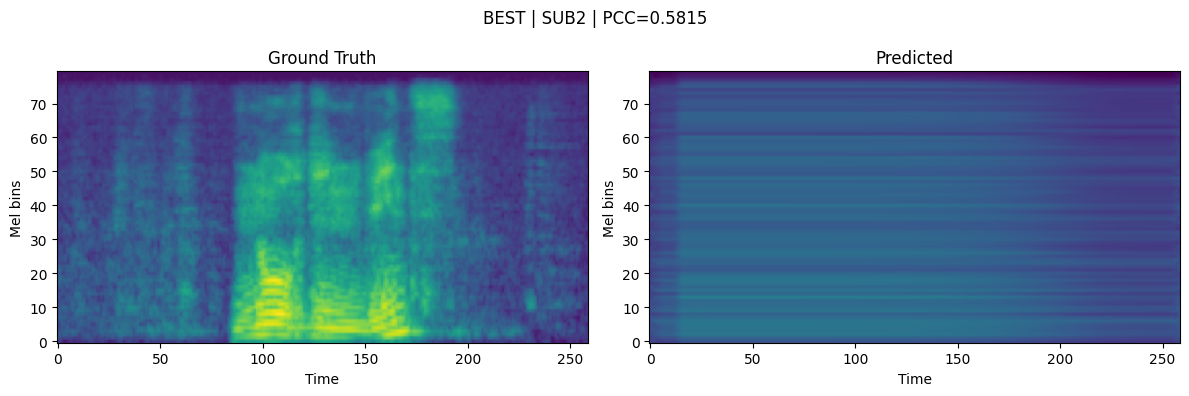

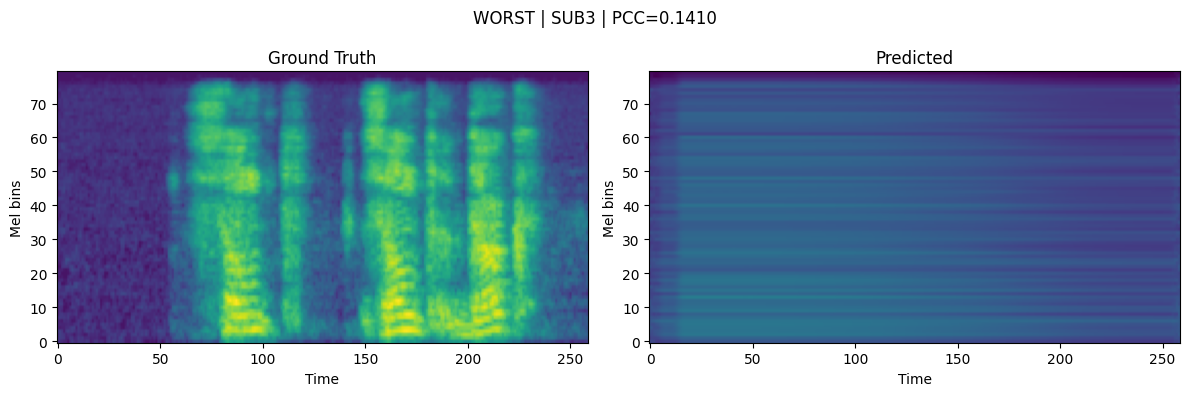

💾 Saved predictions


In [13]:
# ============================================================
# STEP 10: Visualization — Best/Worst Samples
# ============================================================
import matplotlib.pyplot as plt

def plot_mel_pair(pred_mel, true_mel, title="Mel Comparison"):
    vmin = min(true_mel.min(), pred_mel.min())
    vmax = max(true_mel.max(), pred_mel.max())
    plt.figure(figsize=(12, 4))
    plt.suptitle(title)
    plt.subplot(1,2,1)
    plt.imshow(true_mel, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
    plt.title("Ground Truth"); plt.xlabel("Time"); plt.ylabel("Mel bins")
    plt.subplot(1,2,2)
    plt.imshow(pred_mel, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
    plt.title("Predicted"); plt.xlabel("Time"); plt.ylabel("Mel bins")
    plt.tight_layout(); plt.show()

# Find best/worst using hybrid model
best  = {"pcc":-1e9}; worst = {"pcc":1e9}
hybrid.eval()
gc = 0

with torch.no_grad():
    for b, (xb,yb,mask,sid) in enumerate(test_loader):
        xb,yb,mask,sid = [t.to(device) for t in (xb,yb,mask,sid)]
        yp = hybrid(xb, mask, sid)
        yp_np, yb_np, sid_np = yp.cpu().numpy(), yb.cpu().numpy(), sid.cpu().numpy()
        for i in range(xb.size(0)):
            pcc = pearson_corr_np(yp_np[i], yb_np[i])
            sn  = idx2sub[int(sid_np[i])]
            if pcc > best["pcc"]:
                best = {"pcc":pcc,"pred":yp_np[i],"true":yb_np[i],"sub":sn,"idx":gc}
            if pcc < worst["pcc"]:
                worst = {"pcc":pcc,"pred":yp_np[i],"true":yb_np[i],"sub":sn,"idx":gc}
            gc += 1

print(f"TEST samples: {gc}")
print(f"✅ BEST:  {best['sub']} | PCC={best['pcc']:.4f}")
print(f"❌ WORST: {worst['sub']} | PCC={worst['pcc']:.4f}")

plot_mel_pair(best["pred"],  best["true"],
              f"BEST | {best['sub']} | PCC={best['pcc']:.4f}")
plot_mel_pair(worst["pred"], worst["true"],
              f"WORST | {worst['sub']} | PCC={worst['pcc']:.4f}")

np.save("GLOBAL_best_pred.npy",  best["pred"])
np.save("GLOBAL_best_true.npy",  best["true"])
np.save("GLOBAL_worst_pred.npy", worst["pred"])
np.save("GLOBAL_worst_true.npy", worst["true"])
print("💾 Saved predictions")